# Ex9 — PSF engineering: design a phase mask for 3D localisation

3D localisation microscopy reads an emitter's depth from the shape of its image, and a phase mask
in the objective's pupil (a spatial light modulator or a fabricated plate) chooses that shape.
This example designs masks in the two ways the field uses, both of which differentiate through
image formation:

1. **Fisher design.** Minimise the Cramér–Rao lower bound (CRLB) of the position over a depth
   range, with respect to the mask's Zernike coefficients (the route to the Tetrapod PSFs;
   Shechtman et al., PRL 2014). `gx.crlb` computes the bound from forward-mode Jacobians, and
   the design differentiates it once more (reverse mode on top).
2. **End-to-end design.** Train a pixelated mask and a localisation network together on noisy
   simulated frames (DeepSTORM3D; Nehme et al., Nat. Methods 2020), with gradients through the
   camera's Poisson noise.

**Level** L2–L3 (Chains, `gx.crlb`, a Pipeline for training) · **Prerequisites** T1 ·
**Runtime** about 90 s on a GPU. `SMOKE` (set by the test suite) shrinks every size and
iteration count, so the notebook also runs in seconds on a CPU.

In [1]:
import os
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import torch

import gradix as gx
from gradix.special.zernike import zernike_ansi

SMOKE = os.environ.get("GRADIX_SMOKE") == "1"
DEVICE = "cuda" if torch.cuda.is_available() and not SMOKE else "cpu"
plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.titlesize": 9})
_ = torch.manual_seed(0)
COLORS = {
    "open": "0.45",
    "astigmatic": "#1f77b4",
    "designed": "#d62728",
    "learned": "#2ca02c",
    "refined": "#9467bd",
}


def to_numpy(t: torch.Tensor) -> np.ndarray:
    """Return a CPU NumPy copy of a tensor, for plotting."""
    return t.detach().cpu().numpy()

## 1. The microscope and two reference pupils

A water-immersion objective (NA 1.2, 100 nm pixels) images one emitter per frame over a
background of 15 photons per pixel, on a shot-noise-limited camera (`gx.noise.Ideal`) that counts
electrons. An emitter's `photons` are the photons it emits: the objective collects a fraction of
them, which the PSF integrates to. `scene(pupil, z)` builds the Chain for one emitter per image at
the depths `z`. The two references: the open pupil, and astigmatism (a Zernike term, ANSI 5), the
classic depth encoding. The PSFs are scalar: at NA/n = 0.9 absolute bounds need the vectorial
model (M4b), but scalar PSFs suffice to compare masks.

the objective collects 831 of 3000 emitted photons


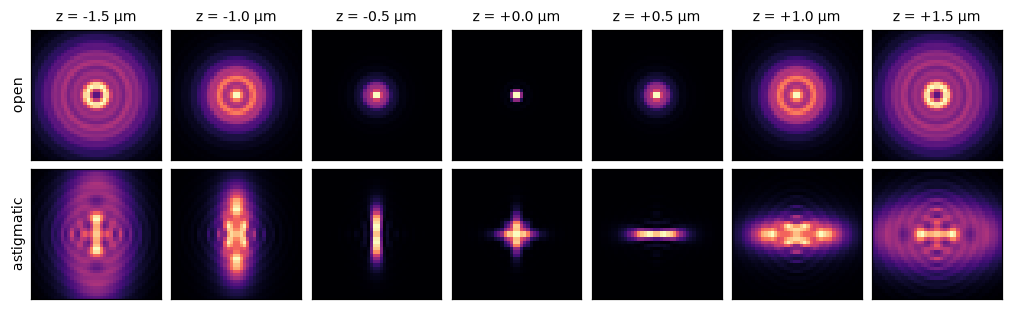

In [2]:
camera = gx.Camera(
    pixel_size=6.5, shape=(24, 24) if SMOKE else (40, 40), noise=gx.noise.Ideal(), unit="e"
)
medium = gx.env.Homogeneous(1.33)
photons, background = 3000.0, 15.0  # emitted photons per emitter; photons per pixel
depths = torch.linspace(-1.5, 1.5, 7, device=DEVICE)  # µm, for PSF displays


def objective(*pupil: gx.pupil.PupilModifier) -> gx.Objective:
    """Return the objective with a phase mask (any pupil modifiers) in its pupil."""
    return gx.Objective(NA=1.2, magnification=65, pupil=pupil)


centre = gx.coords.field_of_view(camera, objective()).to(DEVICE) / 2  # [2] µm


def at_depth(z: torch.Tensor) -> torch.Tensor:
    """Return positions [Z, 1, 3] in µm: one emitter per image, centred, at the depths z [Z]."""
    return torch.cat([centre.to(z).expand(z.shape[0], 1, 2), z.reshape(-1, 1, 1)], -1)


def scene(pupil: tuple[gx.pupil.PupilModifier, ...], z: torch.Tensor) -> gx.Chain:
    """Return the Chain of one centred emitter per image at the depths z [Z] µm, through a pupil."""
    emitter = gx.Emitters(position=at_depth(z), photons=photons, emission=gx.Spectrum.line(0.6))
    imaging = gx.imaging.PointPSF(objective(*pupil), camera, psf="scalar", method="global")
    return gx.Chain(
        emitters={"emitter": emitter}, imaging=imaging, environment=medium, background=background
    )


def show_stacks(pupils: dict[str, tuple[gx.pupil.PupilModifier, ...]]) -> None:
    """Draw each pupil's PSF (background removed) at seven depths, one row per pupil."""
    _, axes = plt.subplots(
        len(pupils),
        len(depths),
        squeeze=False,
        layout="constrained",
        figsize=(1.3 * len(depths), 1.35 * len(pupils)),
    )
    for row, (name, pupil) in enumerate(pupils.items()):
        frames = scene(pupil, depths)(outputs=("expected",)).expected - background
        for col in range(len(depths)):
            ax = axes[row, col]
            ax.imshow(to_numpy(frames[col, 0]), cmap="magma")
            ax.set_xticks([])
            ax.set_yticks([])
            if row == 0:
                ax.set_title(f"z = {depths[col].item():+.1f} µm")
        axes[row, 0].set_ylabel(name)
    plt.show()


astigmatism = gx.pupil.Zernike(coeffs=torch.tensor([0.12], device=DEVICE), indices=(5,))
pupils: dict[str, tuple[gx.pupil.PupilModifier, ...]] = {"open": (), "astigmatic": (astigmatism,)}
show_stacks(pupils)
collected = scene((), depths[3:4])(outputs=("expected",)).expected - background  # at focus
print(f"the objective collects {collected.sum().item():.0f} of {photons:.0f} emitted photons")

## 2. The Cramér–Rao lower bound

No unbiased estimator of the position from one frame beats `σ_i ≥ √(F⁻¹)_ii`, where `F` is the
Fisher information of the frame's pixels under the camera's noise. `gx.crlb(chain, wrt=...)`
evaluates the bound at the Chain's values: it takes the Jacobian `∂μ/∂θ` of the expected frames
by forward-mode AD, one pass per coordinate for the whole batch (every image is its own
problem), and inverts the Fisher information of `gx.detect.fisher`. Fields left out of `wrt`
count as known. It warns that scalar PSFs make bounds optimistic above NA/n = 0.45, which this
notebook accepts, since it compares masks under one model.

CRLB · 3 parameter(s) per image, 0 shared · Jacobian by forward mode
  emitter.position         (60, 1, 3)     median 0.04143 µm (from 0.007677 to 0.1424)
note: shot noise: the Fisher information is exact
note: scalar PSFs at NA/n = 0.902 > 0.45: the bounds are optimistic until the vectorial model lands (M4b, §5.3)


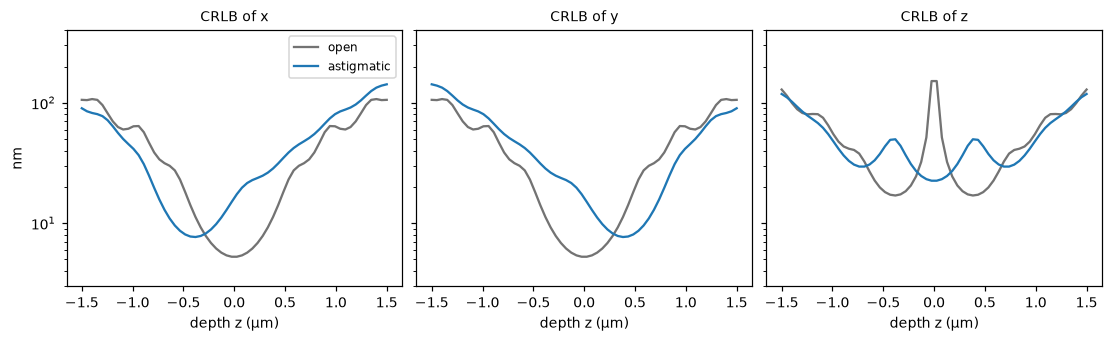

In [3]:
warnings.filterwarnings("ignore", "scalar PSFs", gx.GradixWarning)  # accepted, see above


def crlb(pupil: tuple[gx.pupil.PupilModifier, ...], z: torch.Tensor) -> torch.Tensor:
    """Return the CRLB of (x, y, z) in µm, [Z, 3], of one emitter at each depth in z [Z] µm."""
    return gx.crlb(scene(pupil, z), wrt="emitter.position")["emitter.position"][:, 0]


fine = torch.linspace(-1.5, 1.5, 8 if SMOKE else 60, device=DEVICE)  # even: no point at focus
bounds = {name: crlb(pupil, fine).detach() for name, pupil in pupils.items()}
print(gx.crlb(scene(pupils["astigmatic"], fine), wrt="emitter.position").explain())


def plot_bounds(bounds: dict[str, torch.Tensor]) -> None:
    """Plot the CRLB of x, y and z against depth, one line per pupil."""
    _, axes = plt.subplots(1, 3, figsize=(10.0, 3.0), layout="constrained", sharey=True)
    for axis, ax in enumerate(axes):
        for name, bound in bounds.items():
            ax.semilogy(
                to_numpy(fine), to_numpy(1000 * bound[:, axis]), color=COLORS[name], label=name
            )
        ax.set_title(f"CRLB of {'xyz'[axis]}")
        ax.set_xlabel("depth z (µm)")
        ax.set_ylim(3, 400)
    axes[0].set_ylabel("nm")
    axes[0].legend(fontsize=8)
    plt.show()


plot_bounds(bounds)

Without a mask the z bound diverges at focus, where the PSF's derivative in depth vanishes.
Worse, the open PSF is symmetric about focus, and a bound, being local, cannot see that +z and
−z look the same; section 4 shows what that does to a network. Astigmatism breaks the symmetry
and is precise near focus, but it spreads over many pixels beyond about ±1 µm.

## 3. Fisher design: minimise the bound

The design variable is a Zernike phase mask (ANSI 3 to 20: astigmatism up to the fourth-order
terms), started at the astigmatic pupil. The loss is the mean over depth of `σ_x + σ_y + σ_z`.
The bounds stay differentiable with respect to the Chain's other tensors, so the gradient is
reverse mode (`loss.backward()`) through the forward-mode Jacobian, which every gradix element
supports, and the design is an ordinary PyTorch loop.

120 steps in 8.0 s: mean σx + σy + σz 160 → 70 nm
largest terms: ANSI 13 -0.094 µm, ANSI 11 -0.046 µm, ANSI 5 +0.031 µm, ANSI 3 +0.015 µm


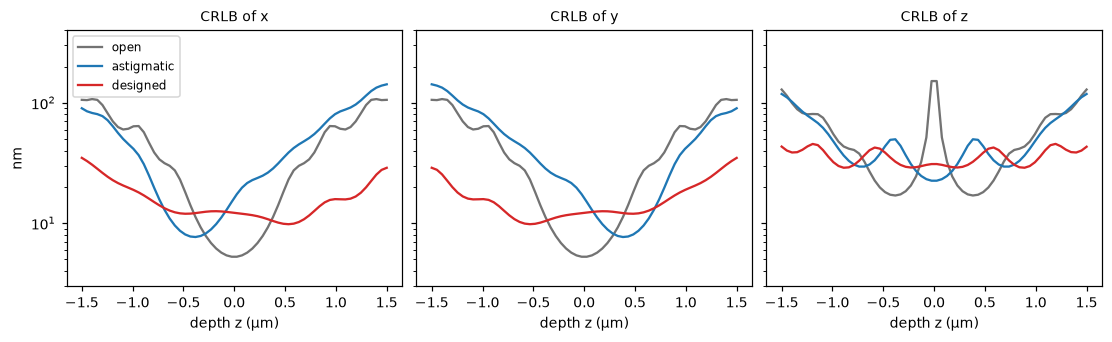

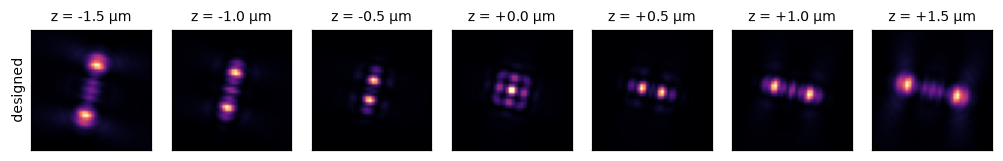

In [4]:
INDICES = tuple(range(3, 21))
coeffs = torch.zeros(len(INDICES), device=DEVICE)
coeffs[INDICES.index(5)] = 0.12  # start from the astigmatic pupil
coeffs.requires_grad_(True)
optimiser = torch.optim.Adam([coeffs], lr=0.01)
coarse = torch.linspace(-1.5, 1.5, 4 if SMOKE else 16, device=DEVICE)
history = []
start = time.perf_counter()
for _ in range(2 if SMOKE else 120):
    bound = crlb((gx.pupil.Zernike(coeffs=coeffs, indices=INDICES),), coarse)
    loss = bound.sum(-1).mean()  # µm
    optimiser.zero_grad()
    loss.backward()  # reverse mode through the forward-mode Jacobian
    optimiser.step()
    history.append(1000 * loss.item())
print(
    f"{len(history)} steps in {time.perf_counter() - start:.1f} s: "
    f"mean σx + σy + σz {history[0]:.0f} → {history[-1]:.0f} nm"
)
designed = gx.pupil.Zernike(coeffs=coeffs.detach().clone(), indices=INDICES)
largest = sorted(zip(INDICES, designed.coeffs.tolist(), strict=True), key=lambda t: -abs(t[1]))
print("largest terms:", ", ".join(f"ANSI {j} {c:+.3f} µm" for j, c in largest[:4]))
pupils["designed"] = (designed,)
bounds["designed"] = crlb((designed,), fine).detach()
plot_bounds(bounds)
show_stacks({"designed": (designed,)})

The designed PSF splits into two lobes that separate along one axis above focus and along the
other below it, the signature of the Tetrapod family, and its bound stays nearly flat across the
3 µm range. The largest terms are secondary astigmatism (ANSI 11 and 13) with a little of the
primary one. The phase over the pupil disc:

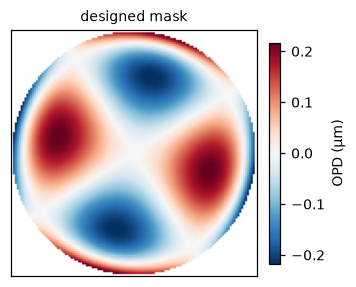

In [5]:
def zernike_map(pupil: gx.pupil.Zernike, q: int) -> torch.Tensor:
    """Return a Zernike mask's OPD in µm on PixelPupil's layout: q × q over u ∈ [−NA, NA]²."""
    u = torch.linspace(-1.0, 1.0, q, dtype=torch.float64)
    uy, ux = torch.meshgrid(u, u, indexing="ij")
    rho, phi = torch.hypot(ux, uy), torch.atan2(uy, ux)
    coeffs = pupil.coeffs.detach().cpu().double()
    return torch.stack(
        [c * zernike_ansi(j, rho, phi) for j, c in zip(pupil.indices, coeffs, strict=True)]
    ).sum(0)


def show_masks(masks: dict[str, torch.Tensor]) -> None:
    """Draw OPD maps [q, q] µm over the pupil disc, on one colour scale."""
    shown = {}
    for name, mask in masks.items():
        u = torch.linspace(-1.0, 1.0, mask.shape[-1])
        disc = torch.hypot(u[None, :], u[:, None]) <= 1.0
        shown[name] = torch.where(disc, mask.detach().cpu().float(), torch.nan)
    limit = max(m[~m.isnan()].abs().quantile(0.99).item() for m in shown.values())
    fig, axes = plt.subplots(
        1, len(shown), figsize=(2.4 * len(shown) + 0.8, 2.5), layout="constrained", squeeze=False
    )
    images = []
    for ax, (name, m) in zip(axes[0], shown.items(), strict=True):
        images.append(ax.imshow(to_numpy(m), cmap="RdBu_r", vmin=-limit, vmax=limit))
        ax.set_title(f"{name} mask")
        ax.set_xticks([])
        ax.set_yticks([])
    fig.colorbar(images[-1], ax=axes[0].tolist(), label="OPD (µm)", shrink=0.9)
    plt.show()


show_masks({"designed": zernike_map(designed, 128)})

## 4. End-to-end design: learn the mask with a network

A bound is a proxy; a user needs a localiser that works. End-to-end design trains the mask and
a network together on simulated noisy frames. A Pipeline renders them (`outputs=("image",)`,
with image keys, so every frame's noise is reproducible), and the camera's Poisson draw passes
gradients to the mask with the scaled straight-through estimator: the frames are exact samples,
the gradient is a biased estimate, and the gradient table says so. The mask is a pixel map
(`gx.pupil.PixelPupil`, 32 × 32 over the pupil), free to become anything.

Four runs train the same small CNN, which regresses the emitter's (x, y, z) from each frame:
the open pupil and the Fisher design (both fixed), a mask learned from a flat start, and the
Fisher design refined end-to-end.

In [6]:
B, STEPS = (8, 3) if SMOKE else (64, 1000)
HALF = torch.tensor([0.3, 0.3, 1.5], device=DEVICE)  # µm: half-ranges of the sampled positions
middle = torch.cat([centre, torch.zeros(1, device=DEVICE)])  # [3] µm


def sample(b: int, generator: torch.Generator | None = None) -> torch.Tensor:
    """Draw b positions [b, 1, 3] µm uniformly within ±HALF of the frame's centre, at focus."""
    return middle + HALF * (2 * torch.rand(b, 1, 3, generator=generator).to(DEVICE) - 1)


def block(inputs: int, outputs: int) -> list[torch.nn.Module]:
    """Return a 3 × 3 convolution with batch normalisation and a ReLU."""
    return [
        torch.nn.Conv2d(inputs, outputs, 3, padding=1),
        torch.nn.BatchNorm2d(outputs),
        torch.nn.ReLU(),
    ]


def network() -> torch.nn.Module:
    """Return a small CNN from frames [B, 1, H, W] to positions [B, 3] in units of HALF."""
    return torch.nn.Sequential(
        *block(1, 32),
        *block(32, 32),
        torch.nn.MaxPool2d(2),
        *block(32, 64),
        torch.nn.MaxPool2d(2),
        *block(64, 64),
        torch.nn.AdaptiveAvgPool2d(5),
        torch.nn.Flatten(),
        torch.nn.Linear(64 * 25, 128),
        torch.nn.ReLU(),
        torch.nn.Linear(128, 3),
    ).to(DEVICE)


def train(
    pupil: tuple[gx.pupil.PupilModifier, ...],
    mask: torch.Tensor | None = None,
    mask_lr: float = 0.0,
) -> tuple[torch.nn.Module, gx.Pipeline]:
    """Train a network on noisy frames through a pupil; with a mask tensor, learn it as well."""
    emitter = gx.Emitters(position=sample(B), photons=photons, emission=gx.Spectrum.line(0.6))
    imaging = gx.imaging.PointPSF(objective(*pupil), camera, psf="scalar", method="global")
    template = gx.Chain(
        emitters={"emitter": emitter}, imaging=imaging, environment=medium, background=background
    )
    pipe = gx.Pipeline(
        gx.tree.to(template, DEVICE),
        outputs=("image",),
        envelope={"emitter.position.z": (-1.5, 1.5)},
    )
    net = network()
    params = [list(net.parameters())] + ([[mask]] if mask is not None else [])
    rates = [1e-3] + ([mask_lr] if mask is not None else [])
    optimiser = torch.optim.Adam(
        [{"params": p, "lr": r} for p, r in zip(params, rates, strict=True)]
    )
    schedule = torch.optim.lr_scheduler.OneCycleLR(optimiser, max_lr=rates, total_steps=STEPS)
    for step in range(STEPS):
        position = sample(B)
        keys = torch.arange(step * B, (step + 1) * B, device=DEVICE)  # a new draw every step
        frames = pipe({"emitter.position": position}, key=keys).image
        loss = (net(frames / 100) - (position[:, 0] - middle) / HALF).square().mean()
        optimiser.zero_grad()
        loss.backward()
        optimiser.step()
        schedule.step()
    return net, pipe


flat = torch.zeros(32, 32, device=DEVICE, requires_grad=True)
seeded = zernike_map(designed, 32).float().to(DEVICE).requires_grad_(True)
pupils["learned"] = (gx.pupil.PixelPupil(opd=flat),)
pupils["refined"] = (gx.pupil.PixelPupil(opd=seeded),)
runs = {}
for name, mask, lr in [
    ("open", None, 0.0),
    ("designed", None, 0.0),
    ("learned", flat, 3e-2),
    ("refined", seeded, 3e-3),
]:
    start = time.perf_counter()
    runs[name] = train(pupils[name], mask, lr)
    print(f"{name:9s} trained in {time.perf_counter() - start:.0f} s")
net, pipe = runs["learned"]
print("\n".join(pipe.gradients(pipe.template)))  # the fields that require gradients

open      trained in 16 s
designed  trained in 20 s
learned   trained in 18 s
refined   trained in 18 s
objective.pupil.0.opd  image: biased


The gradient table lists the learned mask: exact gradients through the expected image, a biased
estimate through the sampled one.

Each network is then tested on the same held-out positions and noise draws (image keys outside
the training range). The dashed line is the Fisher design's bound on z.

pupil      mean CRLB σx+σy+σz   network RMSE: z   lateral
open                145 nm            890 nm     93 nm
designed             68 nm             81 nm     33 nm
learned              70 nm             79 nm     30 nm
refined              68 nm             64 nm     29 nm


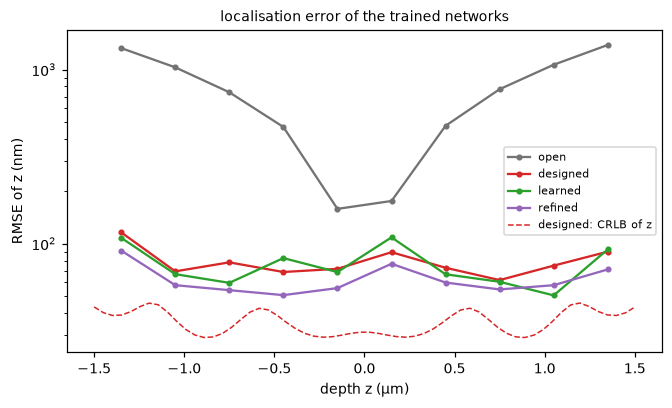

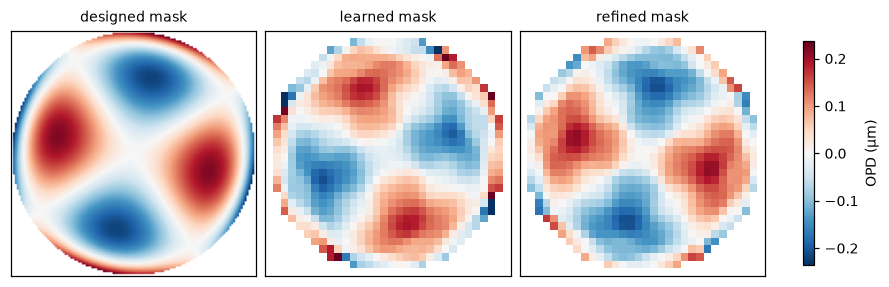

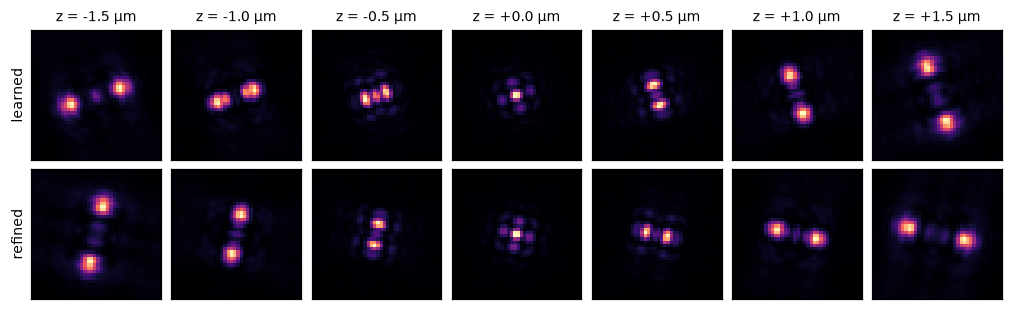

In [7]:
def evaluate(net: torch.nn.Module, pipe: gx.Pipeline) -> tuple[torch.Tensor, torch.Tensor]:
    """Return the depths [M] µm and the localisation errors [M, 3] µm on a fixed test set."""
    generator = torch.Generator().manual_seed(123)
    depth, error = [], []
    net.eval()  # batch normalisation from its running statistics
    with torch.no_grad():
        for i in range(2 if SMOKE else 16):
            position = sample(B, generator)
            keys = torch.arange(10**6 + i * B, 10**6 + (i + 1) * B, device=DEVICE)  # held out
            frames = pipe({"emitter.position": position}, key=keys).image
            error.append(net(frames / 100) * HALF - (position[:, 0] - middle))
            depth.append(position[:, 0, 2])
    return torch.cat(depth), torch.cat(error)


edges = torch.linspace(-1.5, 1.5, 11, device=DEVICE)
fig, ax = plt.subplots(figsize=(6.0, 3.6), layout="constrained")
print("pupil      mean CRLB σx+σy+σz   network RMSE: z   lateral")
for name, (net, pipe) in runs.items():
    depth, error = evaluate(net, pipe)
    index = torch.bucketize(depth, edges[1:-1])
    rmse = torch.stack([error[index == k, 2].square().mean().sqrt() for k in range(10)])
    z, lateral = (
        1000 * error[:, 2].square().mean().sqrt().item(),
        1000 * error[:, :2].square().mean().sqrt().item(),
    )
    bound = crlb(pupils[name], fine).detach()
    print(f"{name:9s} {1000 * bound.sum(-1).mean().item():13.0f} nm {z:14.0f} nm {lateral:6.0f} nm")
    ax.plot(
        to_numpy((edges[1:] + edges[:-1]) / 2),
        to_numpy(1000 * rmse),
        "o-",
        ms=3,
        color=COLORS[name],
        label=name,
    )
ax.plot(
    to_numpy(fine),
    to_numpy(1000 * bounds["designed"][:, 2]),
    "--",
    color=COLORS["designed"],
    lw=1,
    label="designed: CRLB of z",
)
ax.set_yscale("log")
ax.set_xlabel("depth z (µm)")
ax.set_ylabel("RMSE of z (nm)")
ax.set_title("localisation error of the trained networks")
ax.legend(fontsize=7)
plt.show()
show_masks({"designed": zernike_map(designed, 128), "learned": flat, "refined": seeded})
show_stacks({name: pupils[name] for name in ("learned", "refined")})

Without a mask the network cannot tell above from below focus: its z error grows with the
distance from focus, an order of magnitude above the others. The Fisher design flattens the
error over the whole range. The mask learned from a flat start reaches the design's accuracy in
the same thousand steps with the same kind of mask, secondary astigmatism in its own
orientation, and its bound comes close to the Fisher design's without ever computing one.
Refining the design end-to-end does best: its bound barely changes, but this network reads its
PSF more easily, which a bound on unbiased estimators does not measure.

## Recap

- `gx.crlb` turns a Chain into Cramér–Rao bounds: forward-mode Jacobians, the camera's Fisher
  information (`gx.detect.fisher`) and its inverse. The bounds stay differentiable, so a design
  that minimises them is an ordinary PyTorch loop.
- Pupil modifiers compose in `Objective(pupil=...)`: `Zernike` for smooth designs, `PixelPupil`
  for free-form masks; their tensors are ordinary learnable parameters.
- A Pipeline renders sampled frames with gradients through the camera's noise, and its gradient
  table states the quality of every gradient.